In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
import glob
# add code directory to path
import sys
#sys.path.append('/cluster/tufts/hugheslab/kheuto01/code/decision-aware-topk')
from torch_models import PyEPONegativeBinomialRegressionModel, deterministic_bpr

def setup_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

def check_existing_results(seed, location, K):
    return os.path.exists(f'results_seed_{seed}_{location}_{K}.csv')

def load_results(seed, location, K, path_override=None):
    safe_globals = {
        'array': np.array,
        'float32': np.float32,
        'nan': np.nan,
        'inf': np.inf
    }

    def type_converter(x):
        if pd.isna(x):
            return np.nan
        try:
            return eval(x, safe_globals)
        except (SyntaxError, ValueError):
            try:
                return ast.literal_eval(x)
            except (SyntaxError, ValueError):
                return x
            
    if path_override is not None:
        filepath = path_override
    else:
        filepath = f'results_seed_{seed}_{location}_{K}.csv'

    return pd.read_csv(filepath, converters={
        'avg_val_bpr': type_converter,
        'avg_test_bpr': type_converter,
        'trial_val_bprs': type_converter,
        'trial_test_bprs': type_converter,
        'val_nll': type_converter,
        'test_nll': type_converter,
        'param_1': type_converter,
        'param_2': type_converter,
        'param_8': type_converter
    })

def process_experiment_directory(exp_dir, max_param_len, data, device, num_trials, num_ranking_samples, K, val_data, test_data):
    dir_name = os.path.basename(exp_dir)
    params = [param.split('_') for param in dir_name.split('_')]
    model_path = os.path.join(exp_dir, 'best_model.pth')

    if not os.path.exists(model_path):
        return None
    print(f"Num loc: {data['train'][0].shape[1]}")
    print(f"Num fe: {data['train'][0].shape[2]}")
    print(f'Model path: {model_path}')
    model = PyEPONegativeBinomialRegressionModel(
        num_locations=data['train'][0].shape[1],
        num_fixed_effects=data['train'][0].shape[2]
    ).to(device)

    #checkpoint = torch.load(model_path, map_location=device)
    #model.load_state_dict(checkpoint['model_state_dict'])
    print("why")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    trial_val_bpr = []
    trial_test_bpr = []
    trial_test_mae = []
    trial_test_rmse = []
    val_nll = -model.log_likelihood(val_data[2],  torch.cat([val_data[0], val_data[1].unsqueeze(-1)], dim=-1)).detach().cpu().numpy()
    test_nll = -model.log_likelihood(test_data[2], torch.cat([test_data[0], test_data[1].unsqueeze(-1)], dim=-1)).detach().cpu().numpy()

    params_single_tensor = model.params_to_single_tensor()

    for trial in range(num_trials):
        val_dist = model.build_from_single_tensor(params_single_tensor, val_data[0], val_data[1])
        y_sample_TMS = val_dist.sample((num_ranking_samples,)).permute(1, 0, 2)
        ratio_rating_TMS = y_sample_TMS / y_sample_TMS.sum(dim=-1, keepdim=True)
        ratio_rating_TS = ratio_rating_TMS.mean(dim=1)
        ratio_rating_TS = model.ratio_rating(torch.cat([val_data[0], val_data[1].unsqueeze(-1)], dim=-1), 100)
        det_bpr = deterministic_bpr(ratio_rating_TS, val_data[2], K=K)
        trial_val_bpr.append(torch.mean(det_bpr).cpu().numpy())

        test_dist = model.build_from_single_tensor(params_single_tensor, test_data[0], test_data[1])
        y_sample_TMS = test_dist.sample((num_ranking_samples,)).permute(1, 0, 2)
        ratio_rating_TMS = y_sample_TMS / y_sample_TMS.sum(dim=-1, keepdim=True)
        ratio_rating_TS = ratio_rating_TMS.mean(dim=1)
        ratio_rating_TS = model.ratio_rating(torch.cat([test_data[0], test_data[1].unsqueeze(-1)], dim=-1), 100)
        det_bpr = deterministic_bpr(ratio_rating_TS, test_data[2], K=K)
        trial_test_bpr.append(torch.mean(det_bpr).cpu().numpy())

        # calculate test mae and rmse
        trial_test_mae.append(torch.mean(torch.abs(test_dist.mean - test_data[2])).detach().cpu().numpy())
        trial_test_rmse.append(torch.sqrt(torch.mean((test_dist.mean - test_data[2])**2)).detach().cpu().numpy())

    avg_val_bpr = np.mean(trial_val_bpr)
    avg_test_bpr = np.mean(trial_test_bpr)
    avg_test_mae = np.mean(trial_test_mae)
    avg_test_rmse = np.mean(trial_test_rmse)

    return {
        'model_path': model_path,
        'avg_val_bpr': avg_val_bpr,
        'avg_test_bpr': avg_test_bpr,
        'trial_val_bprs': trial_val_bpr,
        'trial_test_bprs': trial_test_bpr,
        'val_nll': val_nll,
        'test_nll': test_nll,
        'avg_test_mae': avg_test_mae,
        'avg_test_rmse': avg_test_rmse,
        'params': params
    }

def save_results(results, params_list, max_param_len, seed, location, K):
    params_df = pd.DataFrame(params_list, columns=[f'param_{i}' for i in range(max_param_len)])
    results_df = pd.concat([results, params_df], axis=1)
    results_df.to_csv(f'results_seed_{seed}_{location}_{K}.csv', index=False)

def run_experiment(seed, location, K, exp_dirs, data, device, num_trials, num_ranking_samples, val_data, test_data):
    setup_seed(seed)

    if check_existing_results(seed, location, K):
        results_df = load_results(seed, location, K)
    else:
        results = []
        params_list = []
        max_param_len = 0

        for e, exp_dir in enumerate(exp_dirs):
            if e % 5 == 0:
                print(f'Processing experiment {e} of {len(exp_dirs)}')

            result = process_experiment_directory(exp_dir, max_param_len, data, device, num_trials, num_ranking_samples, K, val_data, test_data)
            if result:
                results.append(result)
                params_list.append(result['params'])
                max_param_len = max(max_param_len, len(result['params']))

        results_df = pd.DataFrame(results)
        save_results(results_df, params_list, max_param_len, seed, location, K)

    # Add additional processing here as needed
    return results_df

def extract_parameters(results_df):
    results_df['tr'] = results_df['param_8'].apply(lambda x: float(x[0][2:]) if isinstance(x, list) and len(x) > 0 and len(x[0]) < 8 else np.nan)
    results_df['bw'] = results_df['param_1'].apply(lambda x: int(x[0][2:]) if isinstance(x, list) and len(x) > 0 else np.nan)
    results_df['nw'] = results_df['param_2'].apply(lambda x: int(x[0][2:]) if isinstance(x, list) and len(x) > 0 else np.nan)
    return results_df
def generate_colors_and_markers():
    colors = {
        (30, 0): '#1f77b4',  # blue
        (30, 1): '#ff7f0e',  # orange
        (0, 1): '#2ca02c',   # green
        (10, 10): '#9467bd', # purple (SPO+)
        (20, 20): '#c39bd3'  # lighter purple (PG)
    }
    
    markers = {
        (30, 0): 'o',
        (30, 1): 's',
        (0, 1): '^',
        (10, 10): 'D',  # diamond marker for both
        (20, 20): 'D'
    }
    
    labelslist = {
        (30, 0): 'BPR Only',
        (30, 1): 'DAML',
        (0, 1): 'NLL Only',
        (10, 10): 'SPO+',
        (20, 20): 'PG'
    }

    return colors, markers, labelslist


def plot_test_scatter_with_kde(results_df, location, num_ranking_samples, num_trials, seed, K, title_string=None, violin_height=1, legend_loc='best'):
    colors, markers, labelslist = generate_colors_and_markers()
    thresholds = sorted(results_df['tr'].dropna().unique())
    shades_of_orange = list(mcolors.LinearSegmentedColormap.from_list("", ["#fd8d3c", "#f03b20"])(np.linspace(0, 1, len(thresholds))))

    fig, ax = plt.subplots(figsize=(6, 5))

    for bw, nw in [(30, 0), (30, 1), (0, 1)]:
        mask = (results_df['bw'] == bw) & (results_df['nw'] == nw)
        if bw == 30 and nw == 0:
            idx = results_df[mask]['avg_val_bpr'].idxmax()
            kde = gaussian_kde(results_df.loc[idx, 'trial_test_bprs'])
            x_range = np.linspace(min(results_df.loc[idx, 'trial_test_bprs']), max(results_df.loc[idx, 'trial_test_bprs']), 200)
            density = kde(x_range)
            density /= density.max()
            density *= violin_height
            y_lower = -results_df.loc[idx, 'test_nll'] - violin_height / 2
            ax.fill_between(x=x_range, y1=y_lower, y2=y_lower + density, color=colors[(bw, nw)], alpha=0.5)
            ax.scatter(results_df.loc[idx, 'avg_test_bpr'], -results_df.loc[idx, 'test_nll'], 
                       color=colors[(bw, nw)], marker=markers[(bw, nw)], label=labelslist[(bw, nw)])
        elif bw == 30 and nw == 1:
            for i, tr in enumerate(thresholds):
                tr_mask = mask & (results_df['tr'] == tr)
                idx = results_df[tr_mask]['val_nll'].idxmin()
                kde = gaussian_kde(results_df.loc[idx, 'trial_test_bprs'])
                x_range = np.linspace(min(results_df.loc[idx, 'trial_test_bprs']), max(results_df.loc[idx, 'trial_test_bprs']), 200)
                density = kde(x_range)
                density /= density.max()
                density *= violin_height
                y_lower = -results_df.loc[idx, 'test_nll'] - violin_height / 2
                ax.fill_between(x=x_range, y1=y_lower, y2=y_lower + density, color=shades_of_orange[i], alpha=0.5)
                print(f'Threshold: {tr}, BPR: {results_df.loc[idx, "avg_test_bpr"]}, NLL: {results_df.loc[idx, "test_nll"]}')
                ax.scatter(results_df.loc[idx, 'avg_test_bpr'], -results_df.loc[idx, 'test_nll'], 
                           color=shades_of_orange[i], marker=markers[(bw, nw)], 
                           label=f"{labelslist[(bw, nw)]} ($\\epsilon$={tr:.2f})")
        elif bw == 0 and nw == 1:
            idx = results_df[mask]['val_nll'].idxmin()
            kde = gaussian_kde(results_df.loc[idx, 'trial_test_bprs'])
            x_range = np.linspace(min(results_df.loc[idx, 'trial_test_bprs']), max(results_df.loc[idx, 'trial_test_bprs']), 200)
            density = kde(x_range)
            density /= density.max()
            density *= violin_height
            y_lower = -results_df.loc[idx, 'test_nll'] - violin_height / 2
            ax.fill_between(x=x_range, y1=y_lower, y2=y_lower + density, color=colors[(bw, nw)], alpha=0.5)
            ax.scatter(results_df.loc[idx, 'avg_test_bpr'], -results_df.loc[idx, 'test_nll'], 
                       color=colors[(bw, nw)], marker=markers[(bw, nw)], label=labelslist[(bw, nw)])

    if title_string is None:
        title_string = f'{location}, Average Test Performance\nSelected by Best Average Validation Performance'
    ax.set_title(title_string, fontsize=16)
    ax.set_xlabel('Test BPR', fontsize=14)
    ax.set_ylabel('Test Log Likelihood', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)



    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(sorted(zip(labels, handles), key=lambda x: x[0]))
    ax.legend(by_label.values(), by_label.keys(), fontsize=12, loc=legend_loc)
    
    # set ylim
    #ax.set_ylim(-30,0)

    plt.tight_layout()
    plt.savefig(f'results_seed_{seed}_test_scatter_{location}_{K}.pdf', dpi=600)
    plt.show()


def plot_scatter(results_df, location, num_ranking_samples, num_trials, seed, K):
    colors, markers, labelslist = generate_colors_and_markers()
    thresholds = sorted(results_df['tr'].dropna().unique())
    shades_of_green = list(mcolors.LinearSegmentedColormap.from_list("", ["lightgreen", "darkgreen"])(np.linspace(0, 1, len(thresholds))))

    fig, ax = plt.subplots(figsize=(10, 6))

    for bw, nw in [(30, 0), (30, 1), (0, 1)]:
        mask = (results_df['bw'] == bw) & (results_df['nw'] == nw)
        if bw == 30 and nw == 0:
            idx = results_df[mask]['avg_val_bpr'].idxmax()
            ax.scatter(results_df.loc[idx, 'avg_val_bpr'], -results_df.loc[idx, 'test_nll'], 
                       color=colors[(bw, nw)], marker=markers[(bw, nw)], label=labelslist[(bw, nw)])
        elif bw == 30 and nw == 1:
            for i, tr in enumerate(thresholds):
                tr_mask = mask & (results_df['tr'] == tr)
                idx = results_df[tr_mask]['avg_val_bpr'].idxmax()
                ax.scatter(results_df.loc[idx, 'avg_val_bpr'], -results_df.loc[idx, 'test_nll'], 
                           color=shades_of_green[i], marker=markers[(bw, nw)], 
                           label=f"{labelslist[(bw, nw)]} (tr={tr})")
        elif bw == 0 and nw == 1:
            idx = results_df[mask]['avg_val_bpr'].idxmax()
            ax.scatter(results_df.loc[idx, 'avg_val_bpr'], -results_df.loc[idx, 'test_nll'], 
                       color=colors[(bw, nw)], marker=markers[(bw, nw)], label=labelslist[(bw, nw)])

    ax.set_title(f'{location}, Average val performance selected by best average val performance.\n'
                 f'{num_ranking_samples} rankings samples, {num_trials} trials, seed: {seed}')
    ax.set_xlabel(f'Test BPR-{K}')
    ax.set_ylabel('Test Negative Log Likelihood (NLL)')
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(sorted(zip(labels, handles), key=lambda x: x[0]))
    ax.legend(by_label.values(), by_label.keys())
    plt.savefig(f'results_seed_{seed}_val_scatter_{location}_{K}.png')




def plot_violin(results_df, location, seed, K):
    colors, markers, labelslist = generate_colors_and_markers()
    thresholds = sorted(results_df['tr'].dropna().unique())
    shades_of_green = list(mcolors.LinearSegmentedColormap.from_list("", ["lightgreen", "darkgreen"])(np.linspace(0, 1, len(thresholds))))

    total_points = 1 + len(thresholds) + 1
    fig, axes = plt.subplots(1, total_points, figsize=(3 * total_points, 6), sharey=True)
    plot_idx = 0

    all_bpr_values = []
    for bw, nw in [(30, 0), (30, 1), (0, 1)]:
        mask = (results_df['bw'] == bw) & (results_df['nw'] == nw)
        if bw == 30 and nw == 0:
            idx = results_df[mask]['avg_val_bpr'].idxmax()
            all_bpr_values.extend(results_df.loc[idx, 'trial_test_bprs'])
        elif bw == 30 and nw == 1:
            for tr in thresholds:
                tr_mask = mask & (results_df['tr'] == tr)
                idx = results_df[tr_mask]['avg_val_bpr'].idxmax()
                all_bpr_values.extend(results_df.loc[idx, 'trial_test_bprs'])
        elif bw == 0 and nw == 1:
            idx = results_df[mask]['avg_val_bpr'].idxmax()
            all_bpr_values.extend(results_df.loc[idx, 'trial_test_bprs'])

    y_min, y_max = min(all_bpr_values), max(all_bpr_values)
    y_range = y_max - y_min
    y_padding = y_range * 0.05

    for bw, nw in [(30, 0), (30, 1), (0, 1)]:
        mask = (results_df['bw'] == bw) & (results_df['nw'] == nw)
        if bw == 30 and nw == 0:
            idx = results_df[mask]['avg_val_bpr'].idxmax()
            ax = axes[plot_idx]
            ax.violinplot(results_df.loc[idx, 'trial_test_bprs'], showmeans=True)
            ax.set_title(f'BPR only\nBPR={results_df.loc[idx, "avg_test_bpr"]:.3f}')
            ax.collections[0].set_facecolor(colors[(bw, nw)])
            plot_idx += 1
        elif bw == 30 and nw == 1:
            for i, tr in enumerate(thresholds):
                tr_mask = mask & (results_df['tr'] == tr)
                idx = results_df[tr_mask]['avg_val_bpr'].idxmax()
                ax = axes[plot_idx]
                ax.violinplot(results_df.loc[idx, 'trial_test_bprs'], showmeans=True)
                ax.set_title(f'Hybrid (t={tr})\nBPR={results_df.loc[idx, "avg_test_bpr"]:.3f}')
                ax.collections[0].set_facecolor(shades_of_green[i])
                plot_idx += 1
        elif bw == 0 and nw == 1:
            idx = results_df[mask]['avg_val_bpr'].idxmax()
            ax = axes[plot_idx]
            ax.violinplot(results_df.loc[idx, 'trial_test_bprs'], showmeans=True)
            ax.set_title(f'NLL only\nBPR={results_df.loc[idx, "avg_test_bpr"]:.3f}')
            ax.collections[0].set_facecolor(colors[(bw, nw)])
            plot_idx += 1

    for ax in axes:
        ax.set_ylim(y_min - y_padding, y_max + y_padding)
        ax.set_xticks([])

    fig.suptitle(f'{location} Distribution of test BPR values across trials, seed = {seed}')
    fig.text(0.5, 0.02, 'Model variant', ha='center')
    fig.text(0.02, 0.5, 'BPR value', va='center', rotation='vertical')

    plt.tight_layout()
    plt.savefig(f'results_seed_{seed}_test_violins_{location}_{K}.png')
    plt.show()

# Usage:



In [3]:

def load_data(data_dir, bird=False):
    """Load and process training, validation, and test data."""

    if bird:
        bird = 'bird_'
    else:
        bird =  ''
    # Load data
    train_X_df = pd.read_csv(os.path.join(data_dir, f'{bird}train_x.csv'), index_col=[0,1])
    train_Y_df = pd.read_csv(os.path.join(data_dir, f'{bird}train_y.csv'), index_col=[0,1])
    val_X_df = pd.read_csv(os.path.join(data_dir, f'{bird}valid_x.csv'), index_col=[0,1])
    val_Y_df = pd.read_csv(os.path.join(data_dir, f'{bird}valid_y.csv'), index_col=[0,1])
    test_X_df = pd.read_csv(os.path.join(data_dir, f'{bird}test_x.csv'), index_col=[0,1])
    test_Y_df = pd.read_csv(os.path.join(data_dir, f'{bird}test_y.csv'), index_col=[0,1])
    
    def convert_df_to_3d_array(df):
        geoids = sorted(df.index.get_level_values('geoid').unique())
        timesteps = sorted(df.index.get_level_values('timestep').unique())
        geoid_to_idx = {geoid: idx for idx, geoid in enumerate(geoids)}
        
        num_timesteps = len(timesteps)
        print(f'Num timesteps: {num_timesteps}')
        num_locations = len(geoids)
        num_features = len(df.columns)
        X = np.zeros((num_timesteps, num_locations, num_features))
        
        for (geoid, timestep), row in df.iterrows():
            t_idx = timesteps.index(timestep)
            g_idx = geoid_to_idx[geoid]
            X[t_idx, g_idx, :] = row.values
            
        return X, geoids, timesteps

    def convert_y_df_to_2d_array(y_df, geoids, timesteps):
        num_timesteps = len(timesteps)
        num_locations = len(geoids)
        y = np.zeros((num_timesteps, num_locations))
        geoid_to_idx = {geoid: idx for idx, geoid in enumerate(geoids)}
        
        for (geoid, timestep), value in y_df.iloc[:, 0].items():
            t_idx = timesteps.index(timestep)
            g_idx = geoid_to_idx[geoid]
            y[t_idx, g_idx] = value
            
        return y

    # Process training data
    train_X, geoids, timesteps = convert_df_to_3d_array(train_X_df)#.drop(columns='timestep.1'))
    train_time = np.array([timesteps] * len(geoids)).T
    train_y = convert_y_df_to_2d_array(train_Y_df, geoids, timesteps)

    # Process validation data
    val_X, val_geoids, val_timesteps = convert_df_to_3d_array(val_X_df)#.drop(columns='timestep.1'))
    val_time = np.array([val_timesteps] * len(val_geoids)).T
    val_y = convert_y_df_to_2d_array(val_Y_df, val_geoids, val_timesteps)

    # Process test data
    test_X, test_geoids, test_timesteps = convert_df_to_3d_array(test_X_df)#.drop(columns='timestep.1'))
    test_time = np.array([test_timesteps] * len(test_geoids)).T
    test_y = convert_y_df_to_2d_array(test_Y_df, test_geoids, test_timesteps)

    return {
        'train': (torch.tensor(train_X, dtype=torch.float32), 
                 torch.tensor(train_time, dtype=torch.float32),
                 torch.tensor(train_y, dtype=torch.float32)),
        'val': (torch.tensor(val_X, dtype=torch.float32),
               torch.tensor(val_time, dtype=torch.float32),
               torch.tensor(val_y, dtype=torch.float32)),
        'test': (torch.tensor(test_X, dtype=torch.float32),
                torch.tensor(test_time, dtype=torch.float32),
                torch.tensor(test_y, dtype=torch.float32))
    }

In [4]:
location = 'cook'

dirs = {'MA': ('/cluster/tufts/hugheslab/datasets/NSF_OD/cleaned/long/MA', '/cluster/tufts/hugheslab/kheuto01/opioid_hpc_test_long_big/MA/'),
        'cook': ('/cluster/tufts/hugheslab/kheuto01/code/decision-aware-topk/data/cook_county/', '/cluster/tufts/hugheslab/kheuto01/opioid_hpc_test_long_big/cook/'),}
data_dir, base_dir = dirs[location]
K=100



device = 'cuda'
#K=100

data = load_data(data_dir,bird=False)
# Move data to device
val_data = tuple(x.to(device) for x in data['val'])
test_data = tuple(x.to(device) for x in data['test'])
cook_spo_path = '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/cook_spo+_step1e-01'
cook_pg_path = '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/cook_pg_step2e-02_noise1e-02'

cook_spo_results = process_experiment_directory(cook_spo_path, 'na', data, 'cuda', 1000, 1000, K, val_data, test_data)
cook_pg_results = process_experiment_directory(cook_pg_path, 'na', data, 'cuda', 1000, 1000, K, val_data, test_data)


Num timesteps: 4
Num timesteps: 1
Num timesteps: 2
Num loc: 1328
Num fe: 14
Model path: /cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/cook_spo+_step1e-01/best_model.pth
why
Num loc: 1328
Num fe: 14
Model path: /cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/cook_pg_step2e-02_noise1e-02/best_model.pth
why


In [5]:


location = 'MA'
data_dir, base_dir = dirs[location]
data = load_data(data_dir,bird=False)
# Move data to device
val_data = tuple(x.to(device) for x in data['val'])
test_data = tuple(x.to(device) for x in data['test'])

ma_pg_path = '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/MA_pg_step1e-02_noise8e-02'
ma_spo_path = '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/MA_spo+_step2e-03'

ma_spo_results = process_experiment_directory(ma_spo_path, 'na', data, 'cuda', 1000, 1000, K, val_data, test_data)
ma_pg_results = process_experiment_directory(ma_pg_path, 'na', data, 'cuda', 1000, 1000, K, val_data, test_data)

Num timesteps: 9
Num timesteps: 1
Num timesteps: 2
Num loc: 1620
Num fe: 14
Model path: /cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/MA_spo+_step2e-03/best_model.pth
why
Num loc: 1620
Num fe: 14
Model path: /cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/MA_pg_step1e-02_noise8e-02/best_model.pth
why


In [6]:
K=50
location ='asurv'
data_dir = '/cluster/tufts/hugheslab/fmuenc01/code/prob_diff_topk/data_dir/asurv/2monthly_ctxtSize5_small_5yrTrain/'
base_dir = f'/cluster/tufts/hugheslab/kheuto01/new_init_bird/{location}'
bird = True
data = load_data(data_dir,bird=bird)
# Move data to device
val_data = tuple(x.to(device) for x in data['val'])
test_data = tuple(x.to(device) for x in data['test'])

asurv_pg_path = '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250414_run/asurv_pg_step1e-01_noise1e+00'
asurv_spo_path = '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250414_run/asurv_spo+_step8e-03'

asurv_spo_results = process_experiment_directory(asurv_spo_path, 'na', data, 'cuda', 1000, 1000, K, val_data, test_data)
asurv_pg_results = process_experiment_directory(asurv_pg_path, 'na', data, 'cuda', 1000, 1000, K, val_data, test_data)

Num timesteps: 15
Num timesteps: 6
Num timesteps: 6
Num loc: 1338
Num fe: 9
Model path: /cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250414_run/asurv_spo+_step8e-03/best_model.pth
why
Num loc: 1338
Num fe: 9
Model path: /cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250414_run/asurv_pg_step1e-01_noise1e+00/best_model.pth
why


RuntimeError: Error(s) in loading state_dict for PyEPONegativeBinomialRegressionModel:
	size mismatch for b_0: copying a param with shape torch.Size([1620]) from checkpoint, the shape in current model is torch.Size([1328]).
	size mismatch for b_1: copying a param with shape torch.Size([1620]) from checkpoint, the shape in current model is torch.Size([1328]).

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde

def plot_test_scatter_with_kde(results_df, location, num_ranking_samples, num_trials, seed, K, title_string=None, violin_height=1, legend_loc='lower left', x_trans=0.13, y_trans=0.13, break_point=None, upper_ylim=None, lower_ylim=None):
    colors, markers, labelslist = generate_colors_and_markers()
    thresholds = sorted(results_df['tr'].dropna().unique())
    shades_of_orange = list(mcolors.LinearSegmentedColormap.from_list("", ["#fd8d3c", "#f03b20"])(np.linspace(0, 1, len(thresholds))))*2

    selection_criteria = {
        (30, 0): ('avg_val_bpr', 'max'),
        (30, 1): ('avg_val_bpr', 'max'),
        (0, 1): ('val_nll', 'min'),
        (20, 20): ('val_nll', 'min'),
        (10, 10): ('val_nll', 'min')
    }

    if break_point is not None:
        fig, (ax, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})
    else:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax2 = None

    all_handles, all_labels = [], []
    
    for bw, nw in selection_criteria.keys():
        column, operation = selection_criteria[(bw, nw)]
        mask = (results_df['bw'] == bw) & (results_df['nw'] == nw)
        if sum(mask)==0:
            continue
        for i, tr in enumerate(thresholds if bw == 30 and nw == 1 else [None]):
            #if tr is not None and tr != 0.6:
            #    continue
            tr_mask = mask & (results_df['tr'] == tr) if tr is not None else mask
            idx = results_df[tr_mask][column].idxmax() if operation == 'max' else results_df[tr_mask][column].idxmin()
            
            kde = gaussian_kde(results_df.loc[idx, 'trial_test_bprs'])
            x_range = np.linspace(min(results_df.loc[idx, 'trial_test_bprs']), max(results_df.loc[idx, 'trial_test_bprs']), 200)
            density = kde(x_range)
            density /= density.max()
            density *= violin_height
            y_value = -results_df.loc[idx, 'test_nll']

            ax_to_use = ax2 if break_point is not None and y_value < break_point else ax

            y_lower = y_value - violin_height / 2
            y_upper = y_lower + density
            color = shades_of_orange[(-i+5)] if tr is not None else colors[(bw, nw)]
            
            ax_to_use.fill_between(x=x_range, y1=y_lower, y2=y_upper, color=color, alpha=0.5, zorder=0)
            scatter = ax_to_use.scatter(results_df.loc[idx, 'avg_test_bpr'], y_value, color=color, marker=markers[(bw, nw)],
                                        label=f"{labelslist[(bw, nw)]}" if tr is not None else labelslist[(bw, nw)], zorder=1)
            all_handles.append(scatter)
            all_labels.append(scatter.get_label())

    if title_string is None:
        title_string = f'{location}, Average Test Performance\nSelected by Best Average Validation Performance'
    ax.set_title(title_string, fontsize=16)
    ax.set_ylabel('Test Log Likelihood', fontsize=14)
    if ax2:
        ax2.set_xlabel('Test BPR', fontsize=14)
    else:
        ax.set_xlabel('Test BPR', fontsize=14)

    if break_point is not None:
        if upper_ylim is None:
            upper_ylim = (-50, 5)
        if lower_ylim is None:
            lower_ylim = (-500, -150)
        ax.set_ylim(*upper_ylim)
        ax2.set_ylim(*lower_ylim)
        ax.spines['bottom'].set_visible(False)
        ax2.spines['top'].set_visible(False)
        ax.xaxis.tick_top()
        ax2.xaxis.tick_bottom()
        d = .015  # Diagonal line size
        kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
        ax.plot((-d, +d), (-d, +d), **kwargs)
        ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        kwargs.update(transform=ax2.transAxes)
        dy = .03  # Diagonal line size
        ax2.plot((-d, +d), (1 - dy, 1 + dy), **kwargs)
        ax2.plot((1 - d, 1 + d), (1 - dy, 1 + dy), **kwargs)

        # Add dummy points for methods with no data to show in the legend
    for method in [(10, 10), (20, 20)]:
        if labelslist[method] not in all_labels:
            dummy = ax.scatter([], [], color=colors[method], marker=markers[method], label=labelslist[method])
            all_handles.append(dummy)
            all_labels.append(labelslist[method])

    by_label = dict(sorted(zip(all_labels, all_handles), key=lambda x: x[0]))

    fig.legend(by_label.values(), by_label.keys(), fontsize=12, loc=legend_loc, bbox_to_anchor=(x_trans, y_trans), frameon=True)

    plt.tight_layout()  # Adjust layout without legend interference

    plt.savefig(f'results_seed_{seed}_test_scatter_{location}_{K}.pdf', dpi=600)
    plt.show()


def results_to_df(results_dict):
    clean_dict = {}

    for key, value in results_dict.items():
        # Convert lists of numpy arrays to lists of floats
        if isinstance(value, list):
            clean_list = []
            for item in value:
                if isinstance(item, np.ndarray):
                    clean_list.append(item.item())  # array(0.5) -> 0.5
                else:
                    clean_list.append(item)
            clean_dict[key] = [clean_list]
        
        # Convert individual numpy scalars to native Python
        elif isinstance(value, np.generic):
            clean_dict[key] = [value.item()]
        
        # Leave other types as-is (string, float, int, etc.), but wrap in list
        else:
            clean_dict[key] = [value]

    return pd.DataFrame(clean_dict)

In [20]:
location = 'cook'

dirs = {'MA': ('/cluster/tufts/hugheslab/datasets/NSF_OD/cleaned/long/MA', '/cluster/tufts/hugheslab/kheuto01/opioid_hpc_test_long_big/MA/'),
        'cook': ('/cluster/tufts/hugheslab/datasets/NSF_OD/cleaned/cook', '/cluster/tufts/hugheslab/kheuto01/opioid_hpc_test_long_big/cook/'),
        'asurv': ('/cluster/tufts/hugheslab/fmuenc01/code/prob_diff_topk/data_dir/asurv/2monthly_ctxtSize5_small_5yrTrain/',
                  '/cluster/tufts/hugheslab/kheuto01/new_init_bird/asurv')}
data_dir, base_dir = dirs[location]


bird=False
K=100
'''

K=50
location ='asurv'
data_dir = '/cluster/tufts/hugheslab/fmuenc01/code/prob_diff_topk/data_dir/asurv/2monthly_ctxtSize5_small_5yrTrain/'
base_dir = f'/cluster/tufts/hugheslab/fmuenc01/bird_zero_rand_K{K}_8000_bigFix/{location}'
bird=True

'''
exp_dirs = glob.glob(os.path.join(base_dir, "K*"))

device = 'cuda'
#K=100
data = load_data(data_dir,bird=bird)
seed=42

num_ranking_samples = 1000
num_trials = 1000
# Move data to device
val_data = tuple(x.to(device) for x in data['val'])
test_data = tuple(x.to(device) for x in data['test'])
results_df = run_experiment(seed,location, K, exp_dirs, data, device, 1000, 1000, val_data, test_data)
results_df = extract_parameters(results_df)
#plot_scatter(results_df, location, num_ranking_samples, num_trials, seed, K)
#plot_violin(results_df, location, seed, K)

# filter results_df to avg_val_bpr > the avg_val_bpr of the best row with nw=1 and bw=0
mask = (results_df['bw'] == 0) & (results_df['nw'] == 1)
best_nw1_bw0 = results_df[mask]['avg_val_bpr'].max()
# apply this filter only to bw=30, nw=1 models, dont filter other models
mask = (results_df['bw'] == 30) & (results_df['nw'] == 1)
mask = mask | ((results_df['bw'] == 0) & (results_df['nw'] == 0))
results_df = results_df[~mask | (results_df['avg_val_bpr'] > best_nw1_bw0)]

# Flatten the dictionary by excluding fields with non-scalar values
cook_pg_df = results_to_df(cook_pg_results)
cook_pg_df['method'] = 'pg'
cook_pg_df['bw'] = 20
cook_pg_df['nw'] = 20
cook_spo_df = results_to_df(cook_spo_results)
cook_spo_df['method'] = 'spo+'
cook_spo_df['bw'] = 10
cook_spo_df['nw'] = 10
# concatenate cook dfs to results_df
results_df = pd.concat([results_df, cook_pg_df, cook_spo_df], ignore_index=True)

Num timesteps: 4
Num timesteps: 1
Num timesteps: 2


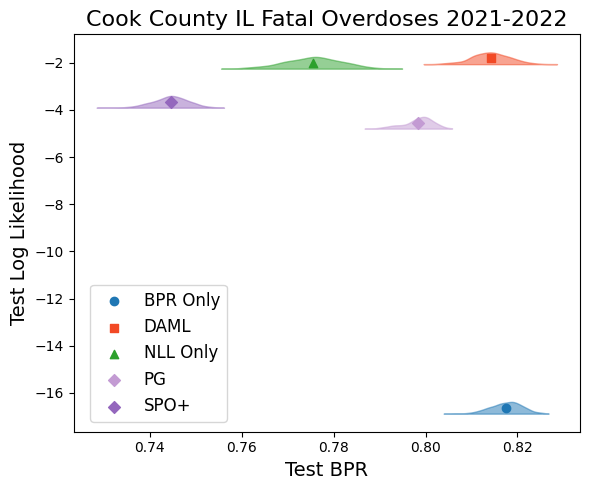

In [21]:
plot_test_scatter_with_kde(results_df, location, num_ranking_samples, num_trials, seed, K, violin_height=0.5, 
                           title_string='Cook County IL Fatal Overdoses 2021-2022', legend_loc='lower right', x_trans=0.4)#br

In [22]:
location = 'MA'

dirs = {'MA': ('/cluster/tufts/hugheslab/datasets/NSF_OD/cleaned/long/MA', '/cluster/tufts/hugheslab/kheuto01/opioid_hpc_test_long_big/MA/'),
        'cook': ('/cluster/tufts/hugheslab/datasets/NSF_OD/cleaned/cook', '/cluster/tufts/hugheslab/kheuto01/opioid_hpc_test_long_big/cook/'),
        'asurv': ('/cluster/tufts/hugheslab/fmuenc01/code/prob_diff_topk/data_dir/asurv/2monthly_ctxtSize5_small_5yrTrain/',
                  '/cluster/tufts/hugheslab/kheuto01/new_init_bird/asurv')}
data_dir, base_dir = dirs[location]


bird=False
K=100
'''

K=50
location ='asurv'
data_dir = '/cluster/tufts/hugheslab/fmuenc01/code/prob_diff_topk/data_dir/asurv/2monthly_ctxtSize5_small_5yrTrain/'
base_dir = f'/cluster/tufts/hugheslab/fmuenc01/bird_zero_rand_K{K}_8000_bigFix/{location}'
bird=True

'''
exp_dirs = glob.glob(os.path.join(base_dir, "K*"))

device = 'cuda'
#K=100
data = load_data(data_dir,bird=bird)
seed=42

num_ranking_samples = 1000
num_trials = 1000
# Move data to device
val_data = tuple(x.to(device) for x in data['val'])
test_data = tuple(x.to(device) for x in data['test'])
results_df = run_experiment(seed,location, K, exp_dirs, data, device, 1000, 1000, val_data, test_data)
results_df = extract_parameters(results_df)
#plot_scatter(results_df, location, num_ranking_samples, num_trials, seed, K)
#plot_violin(results_df, location, seed, K)

# filter results_df to avg_val_bpr > the avg_val_bpr of the best row with nw=1 and bw=0
mask = (results_df['bw'] == 0) & (results_df['nw'] == 1)
best_nw1_bw0 = results_df[mask]['avg_val_bpr'].max()
# apply this filter only to bw=30, nw=1 models, dont filter other models
mask = (results_df['bw'] == 30) & (results_df['nw'] == 1)
mask = mask | ((results_df['bw'] == 0) & (results_df['nw'] == 0))
results_df = results_df[~mask | (results_df['avg_val_bpr'] > best_nw1_bw0)]

# Flatten the dictionary by excluding fields with non-scalar values
ma_pg_df = results_to_df(ma_pg_results)
ma_pg_df['method'] = 'pg'
ma_pg_df['bw'] = 20
ma_pg_df['nw'] = 20
ma_spo_df = results_to_df(ma_spo_results)
ma_spo_df['method'] = 'spo+'
ma_spo_df['bw'] = 10
ma_spo_df['nw'] = 10
# concatenate cook dfs to results_df
results_df = pd.concat([results_df, ma_pg_df, ma_spo_df], ignore_index=True)

Num timesteps: 9
Num timesteps: 1
Num timesteps: 2


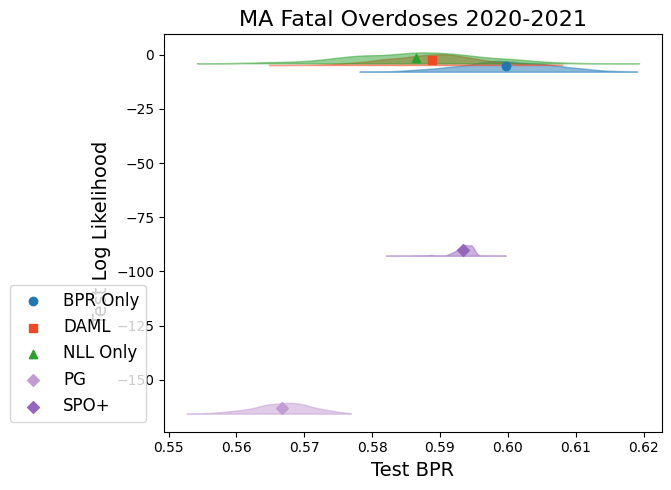

In [23]:
plot_test_scatter_with_kde(results_df, location, num_ranking_samples, num_trials, seed, K, violin_height=5, 
                           title_string='MA Fatal Overdoses 2020-2021', legend_loc='lower right')

In [272]:
results_df.sort_values('avg_val_bpr', ascending=False)
results_df.loc[(results_df['bw'] == 30) & (results_df['nw'] == 0)].nlargest(1, 'avg_val_bpr')
results_df.sort_values('val_nll', ascending=True)
results_df.loc[(results_df['bw'] == 30) & (results_df['nw'] == 1)].nsmallest(1, 'val_nll')
#results_df.loc[(results_df['bw'] == 0) & (results_df['nw'] == 1)].nlargest(1, 'avg_val_bpr')

,model_path,avg_val_bpr,avg_test_bpr,trial_val_bprs,trial_test_bprs,val_nll,test_nll,avg_test_mae,avg_test_rmse,params,...,param_7,param_8,param_9,param_10,param_11,param_12,param_13,tr,bw,nw
31,/cluster/tufts/hugheslab/fmuenc01/bird_zero_ra...,0.336505,0.295306,"[0.33833545, 0.33961475, 0.33399534, 0.3342056...","[0.30393818, 0.29570502, 0.29720417, 0.3037538...",1.085366,0.798348,0.43136,2.516083,"[['K50'], ['bw30'], ['nw1'], ['ss0.01'], ['nss...",...,['sig0.01'],[tr0.65],['studyasurv'],['timescale2monthly'],['ctxtSize5'],['small'],['5yrTrain'],0.65,30,1


In [12]:
data['train'][0].shape

torch.Size([15, 1338, 9])

In [60]:


K=50
location ='asurv'
data_dir = '/cluster/tufts/hugheslab/fmuenc01/code/prob_diff_topk/data_dir/asurv/2monthly_ctxtSize5_small_5yrTrain/'
base_dir = f'/cluster/tufts/hugheslab/kheuto01/new_init_bird/asurv'
bird=True


exp_dirs = glob.glob(os.path.join(base_dir, "K*"))

device = 'cuda'
#K=100
data = load_data(data_dir,bird=bird)
seed=42

num_ranking_samples = 1000
num_trials = 1000
# Move data to device
val_data = tuple(x.to(device) for x in data['val'])
test_data = tuple(x.to(device) for x in data['test'])
results_df = run_experiment(seed,location, K, exp_dirs, data, device, 1000, 1000, val_data, test_data)
# Expand the 'params' column into multiple columns
params_expanded = results_df['params'].apply(lambda x: [p[0] for p in x]).apply(pd.Series)

# Rename the new columns
params_expanded.columns = [f'param_{i}' for i in range(params_expanded.shape[1])]

# Concatenate with original DataFrame (optional)
#results_df = pd.concat([results_df.drop(columns='params'), params_expanded], axis=1)
results_df = extract_parameters(results_df)
#plot_scatter(results_df, location, num_ranking_samples, num_trials, seed, K)
#plot_violin(results_df, location, seed, K)


# filter results_df to avg_val_bpr > the avg_val_bpr of the best row with nw=1 and bw=0
mask = (results_df['bw'] == 0) & (results_df['nw'] == 1)
best_nw1_bw0 = results_df[mask]['avg_val_bpr'].max()
# apply this filter only to bw=30, nw=1 models, dont filter other models
mask = (results_df['bw'] == 30) & (results_df['nw'] == 1)
mask = mask | ((results_df['bw'] == 0) & (results_df['nw'] == 0))
results_df = results_df[~mask | (results_df['avg_val_bpr'] > best_nw1_bw0)]





Num timesteps: 15
Num timesteps: 6
Num timesteps: 6


In [61]:
def extract_parameters_fix(results_df):
    results_df['tr'] = results_df['param_8'].apply(lambda x: float(x[0][2:]) if isinstance(x, str) and len(x) > 0 and len(x[0]) < 8 and len(x[0])>3 else np.nan)
    results_df['bw'] = results_df['param_1'].apply(lambda x: int(x[0][2:]) if isinstance(x, str) and len(x) > 0 else np.nan)
    results_df['nw'] = results_df['param_2'].apply(lambda x: int(x[0][2:]) if isinstance(x, str) and len(x) > 0 else np.nan)
    return results_df

In [63]:
#results_df = extract_parameters_fix(results_df)

In [64]:
results_df[['model_path', 'avg_val_bpr', 'val_nll', 'avg_test_bpr', 'test_nll', 'bw', 'nw', 'tr', 'param_1', 'param_2']].to_csv('~/code/prob_diff_topk/newrun.csv')

In [ ]:
old_results_df = load_results(1,2,3,path_override='~/whatoldresults.csv')
old_results_df = extract_parameters(old_results_df)
short_results = load_results(1,2,3,path_override='~/asurvshortcut.csv')
short_results = extract_parameters(short_results)
# limit to just bw=30 nw =0
combined_results = pd.concat([short_results[(short_results['bw'] == 30) & (short_results['nw'] == 1)],
                               old_results_df[(old_results_df['bw'] == 30) & (old_results_df['nw'] == 0)],
                                short_results[(short_results['bw'] == 0) & (short_results['nw'] == 1)]], ignore_index=True)
combined_results = pd.concat([short_results, old_results_df], ignore_index=True)
combined_results=results_df
# Flatten the dictionary by excluding fields with non-scalar values
asurv_pg_df = results_to_df(asurv_pg_results)
asurv_pg_df['method'] = 'pg'
asurv_pg_df['bw'] = 20
asurv_pg_df['nw'] = 20
asurv_spo_df = results_to_df(asurv_spo_results)
asurv_spo_df['method'] = 'spo+'
asurv_spo_df['bw'] = 10
asurv_spo_df['nw'] = 10
# concatenate cook dfs to results_df
combined_results = pd.concat([combined_results,asurv_pg_df, asurv_spo_df], ignore_index=True)

In [78]:
#combined_results[(combined_results['bw']==30) & (combined_results['nw']==1)]

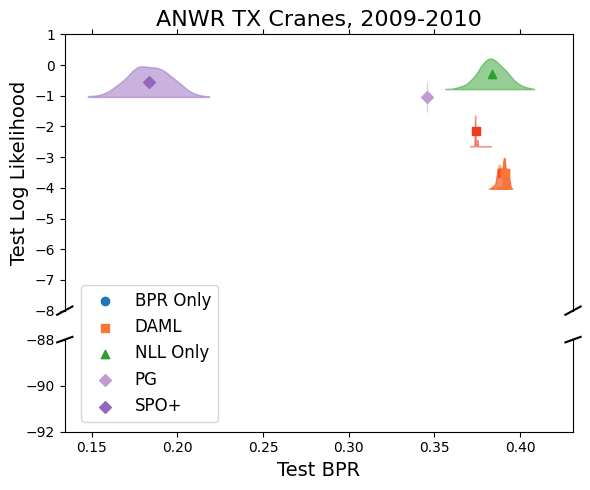

In [77]:
plot_test_scatter_with_kde(combined_results, location, num_ranking_samples, num_trials, seed, K, violin_height=1, 
                           title_string='ANWR TX Cranes, 2009-2010', legend_loc='lower left',x_trans=0.13, y_trans=0.13, break_point=-4, upper_ylim=(-8, 1), lower_ylim=(-92, -88)) 

In [12]:
combined_results.to_csv('everything_asurv.csv')

In [39]:
combined_results = pd.concat([results_df, old_results_df], ignore_index=True)

In [386]:
old_results_df[(old_results_df['bw'] == 0) & (old_results_df['nw'] == 1)].model_path.values

array(['/cluster/tufts/hugheslab/fmuenc01/bird_zero_rand_K50_8000_bigFix/asurv/K50_bw0_nw1_ss0.001_nss100_nps100_seed360_studyasurv_timescale2monthly_ctxtSize5_small_5yrTrain/best_model.pth',
       '/cluster/tufts/hugheslab/fmuenc01/bird_zero_rand_K50_8000_bigFix/asurv/K50_bw0_nw1_ss0.01_nss100_nps100_seed360_studyasurv_timescale2monthly_ctxtSize5_small_5yrTrain/best_model.pth'],
      dtype=object)

In [54]:
checkpoint['model_state_dict']['beta']

tensor([-0.8947, -0.6979,  0.0171, -0.3890, -0.2763,  0.2258, -0.8918, -1.1150,
        -1.3965], device='cuda:0')

In [55]:
model.state_dict()['beta']

tensor([-1.5710,  2.0461,  0.9633,  0.1218,  1.5949, -0.6451,  0.0608,  0.3293,
        -0.5482,  0.2151, -0.1624, -1.3634, -0.2331, -0.1711], device='cuda:0')

In [56]:
model.num_fixed_effects

14

In [60]:
checkpoint

{'epoch': 0,
 'model_state_dict': OrderedDict([('beta_0',
               tensor([-0.0270], device='cuda:0')),
              ('beta',
               tensor([-0.8947, -0.6979,  0.0171, -0.3890, -0.2763,  0.2258, -0.8918, -1.1150,
                       -1.3965], device='cuda:0')),
              ('b_0', tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0')),
              ('b_1', tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0')),
              ('log_sigma_0', tensor([-0.7916], device='cuda:0')),
              ('log_sigma_1', tensor([0.6370], device='cuda:0')),
              ('rho', tensor([-0.0376], device='cuda:0')),
              ('siginv_theta', tensor([-0.7352], device='cuda:0'))]),
 'optimizer_state_dict': {'state': {0: {'step': tensor(4., device='cuda:0'),
    'exp_avg': tensor([0.], device='cuda:0'),
    'exp_avg_sq': tensor([0.], device='cuda:0')},
   1: {'step': tensor(4., device='cuda:0'),
    'exp_avg': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
   

In [349]:
old_results_df['param_2']

0     ['nw1']
1     ['nw1']
2     ['nw0']
3     ['nw0']
4     ['nw0']
5     ['nw0']
6     ['nw0']
7     ['nw0']
8     ['nw0']
9     ['nw0']
10    ['nw0']
11    ['nw1']
12    ['nw1']
13    ['nw1']
14    ['nw1']
15    ['nw1']
16    ['nw1']
17    ['nw1']
18    ['nw1']
19    ['nw1']
20    ['nw1']
21    ['nw1']
22    ['nw1']
23    ['nw1']
24    ['nw1']
25    ['nw1']
26    ['nw1']
27    ['nw1']
28    ['nw1']
29    ['nw1']
30    ['nw1']
31    ['nw1']
32    ['nw1']
33    ['nw1']
34    ['nw1']
35    ['nw1']
36    ['nw1']
37    ['nw1']
38    ['nw1']
39    ['nw1']
40    ['nw1']
Name: param_2, dtype: object

In [40]:
test_data[2].sum()/2

tensor(1818.5000, device='cuda:0')